In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")



# Imports for classification models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [8]:
def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

# Set up evaluation function


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values

        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

# Lung Integration

# Data preprocessing

In [2]:
adata=sc.read_h5ad("colon_merged.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

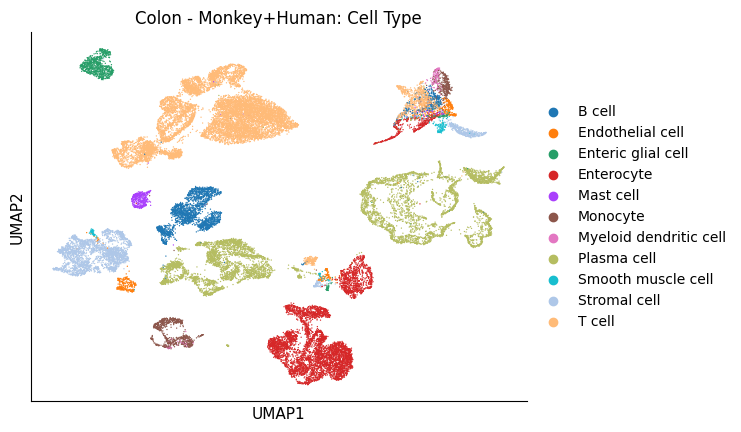

In [10]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Colon - Monkey+Human: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

In [11]:

# Normalize and PCA
sc.pp.normalize_total(adata, target_sum=1e4)   # Normalize to 10,000 counts per cell
sc.pp.log1p(adata)                              # Log transform

sc.pp.highly_variable_genes(adata, n_top_genes=2000)  # Select top 2000 HVGs
adata = adata[:, adata.var.highly_variable]     # Filter to HVGs

sc.pp.scale(adata, max_value=10)               # Scale data
sc.tl.pca(adata, svd_solver='arpack')          # PCA


In [12]:
adata

AnnData object with n_obs × n_vars = 32636 × 2000
    obs: 'cell_type', 'species', 'assay'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [14]:
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)                              

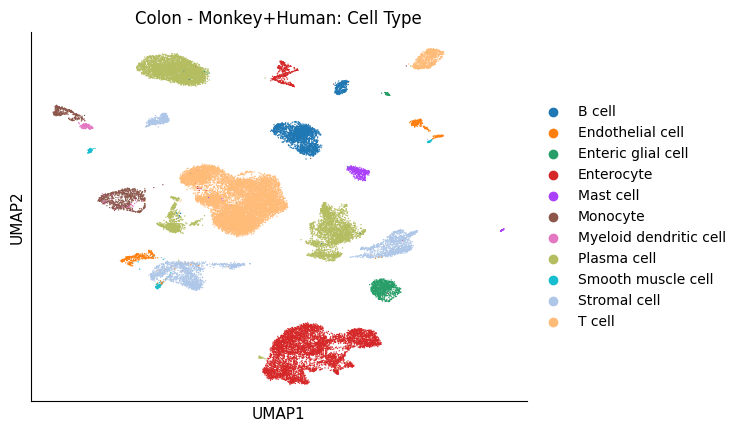

In [15]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Colon - Monkey+Human: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

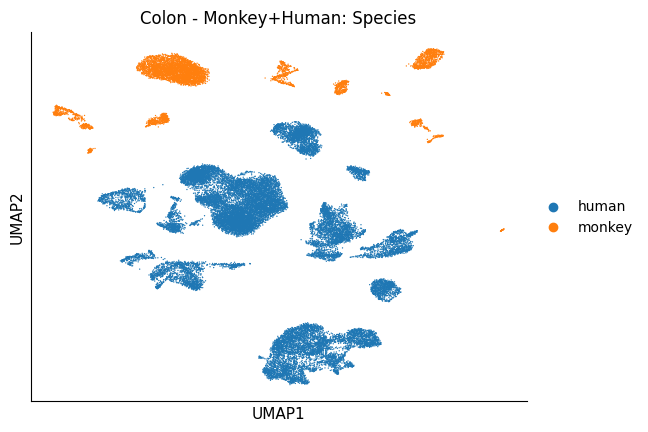

In [16]:
ax = sc.pl.umap(
    adata,
    color='species',
    frameon=True,
    title=[
        "Colon - Monkey+Human: Species"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [17]:
label_keys = ['cell_type', 'species']
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_pca")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

Silhouette scores: {'cell_type': 0.24346484243869781, 'species': 0.2224818468093872}
LISI scores: {'cell_type': 1.0126018550855822, 'species': 1.0008041325323278}


## Label Transfer Human=>Monkey

In [28]:
train_data = adata[adata.obs['species'] == 'human'].copy()
test_data  = adata[adata.obs['species'] == 'monkey'].copy()

X_train = train_data.X
X_test  = test_data.X

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [29]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.8576214405360134
                        precision    recall  f1-score   support

                B cell       0.47      0.99      0.63       326
      Endothelial cell       0.96      0.67      0.79       275
    Enteric glial cell       0.92      1.00      0.96        70
            Enterocyte       1.00      0.95      0.97       405
             Mast cell       0.88      1.00      0.93        49
              Monocyte       0.94      0.38      0.54       334
Myeloid dendritic cell       0.33      0.97      0.49       137
           Plasma cell       1.00      0.87      0.93      3698
    Smooth muscle cell       0.03      0.03      0.03       126
          Stromal cell       0.77      1.00      0.87       407
                T cell       0.98      0.98      0.98       740

              accuracy                           0.86      6567
             macro avg       0.75      0.80      0.74      6567
          weighted avg       0.92      0.86  

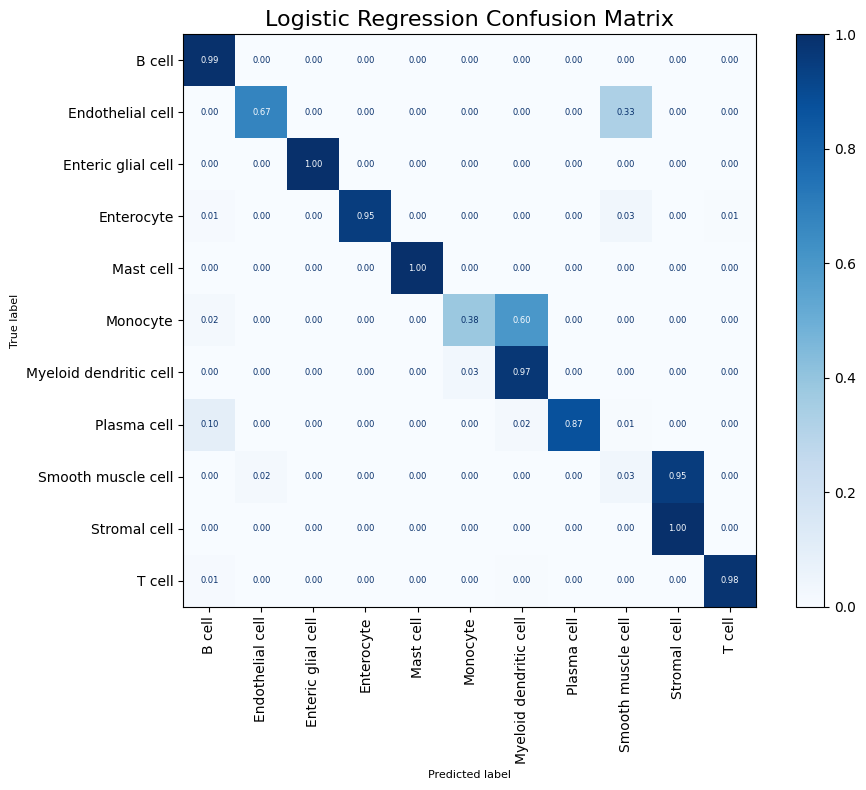


=== k-NN ===
Accuracy: 0.9258413278513781
                        precision    recall  f1-score   support

                B cell       0.99      0.88      0.93       326
      Endothelial cell       0.99      0.75      0.85       275
    Enteric glial cell       0.94      0.96      0.95        70
            Enterocyte       1.00      0.91      0.95       405
             Mast cell       0.96      1.00      0.98        49
              Monocyte       0.72      0.96      0.82       334
Myeloid dendritic cell       0.00      0.00      0.00       137
           Plasma cell       0.97      0.99      0.98      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.75      1.00      0.86       407
                T cell       0.96      0.96      0.96       740

              accuracy                           0.93      6567
             macro avg       0.75      0.76      0.75      6567
          weighted avg       0.91      0.93      0.91      

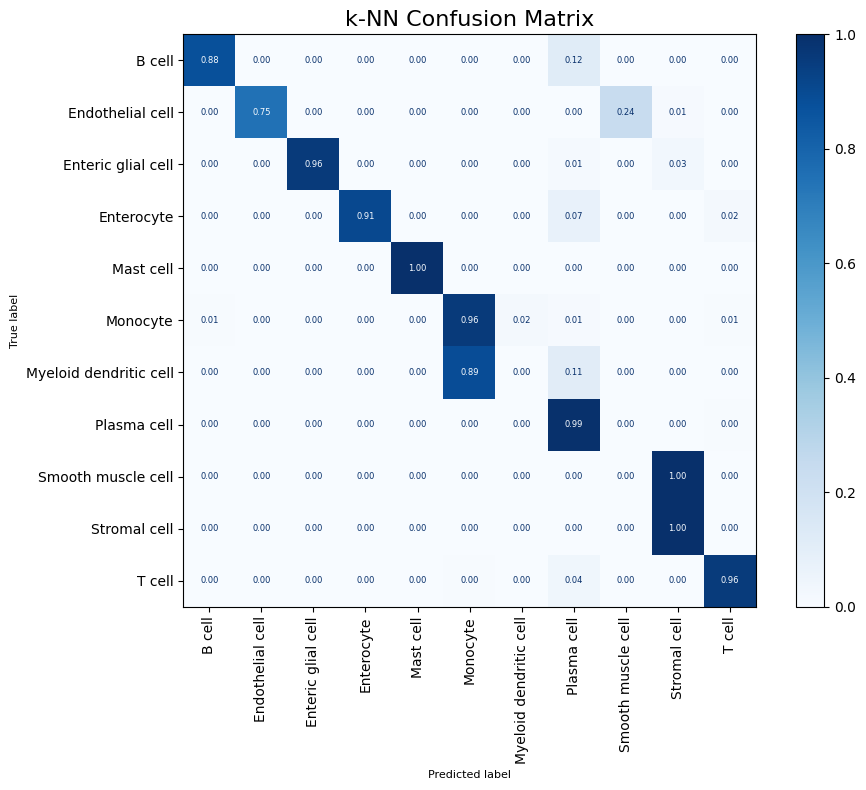

In [30]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

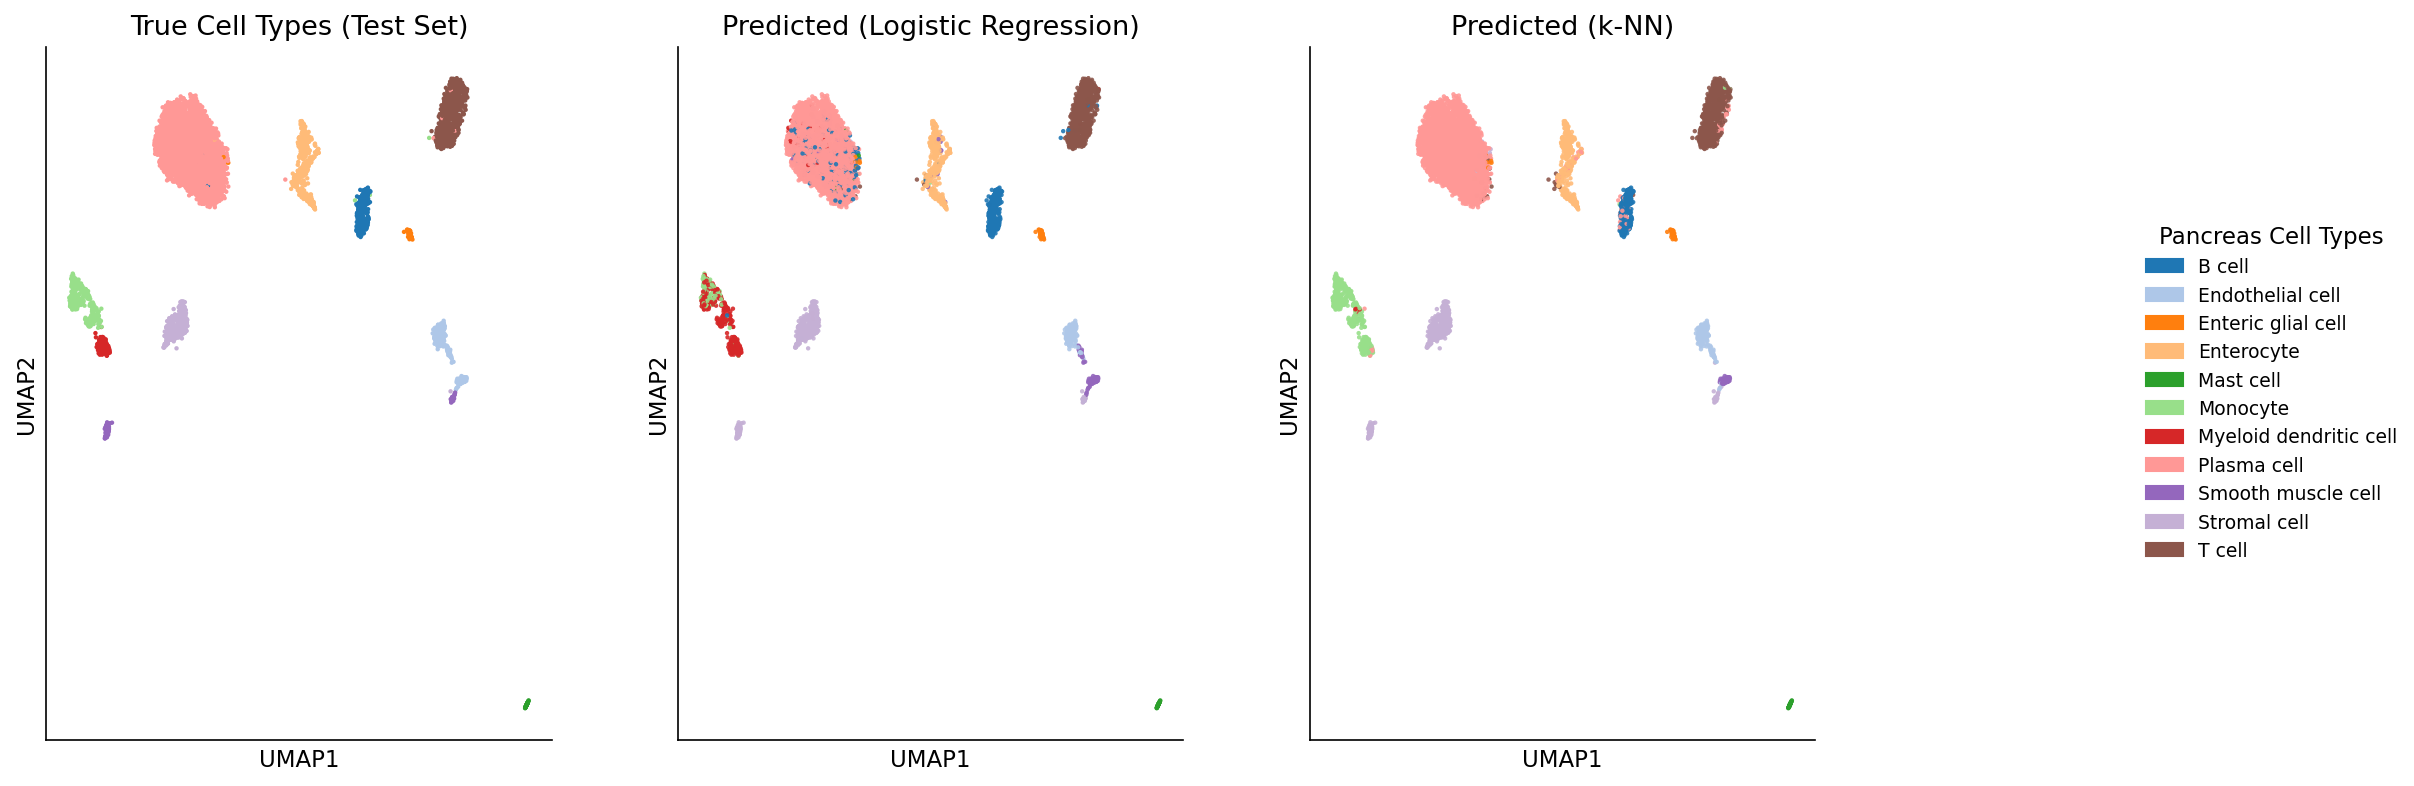

In [31]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

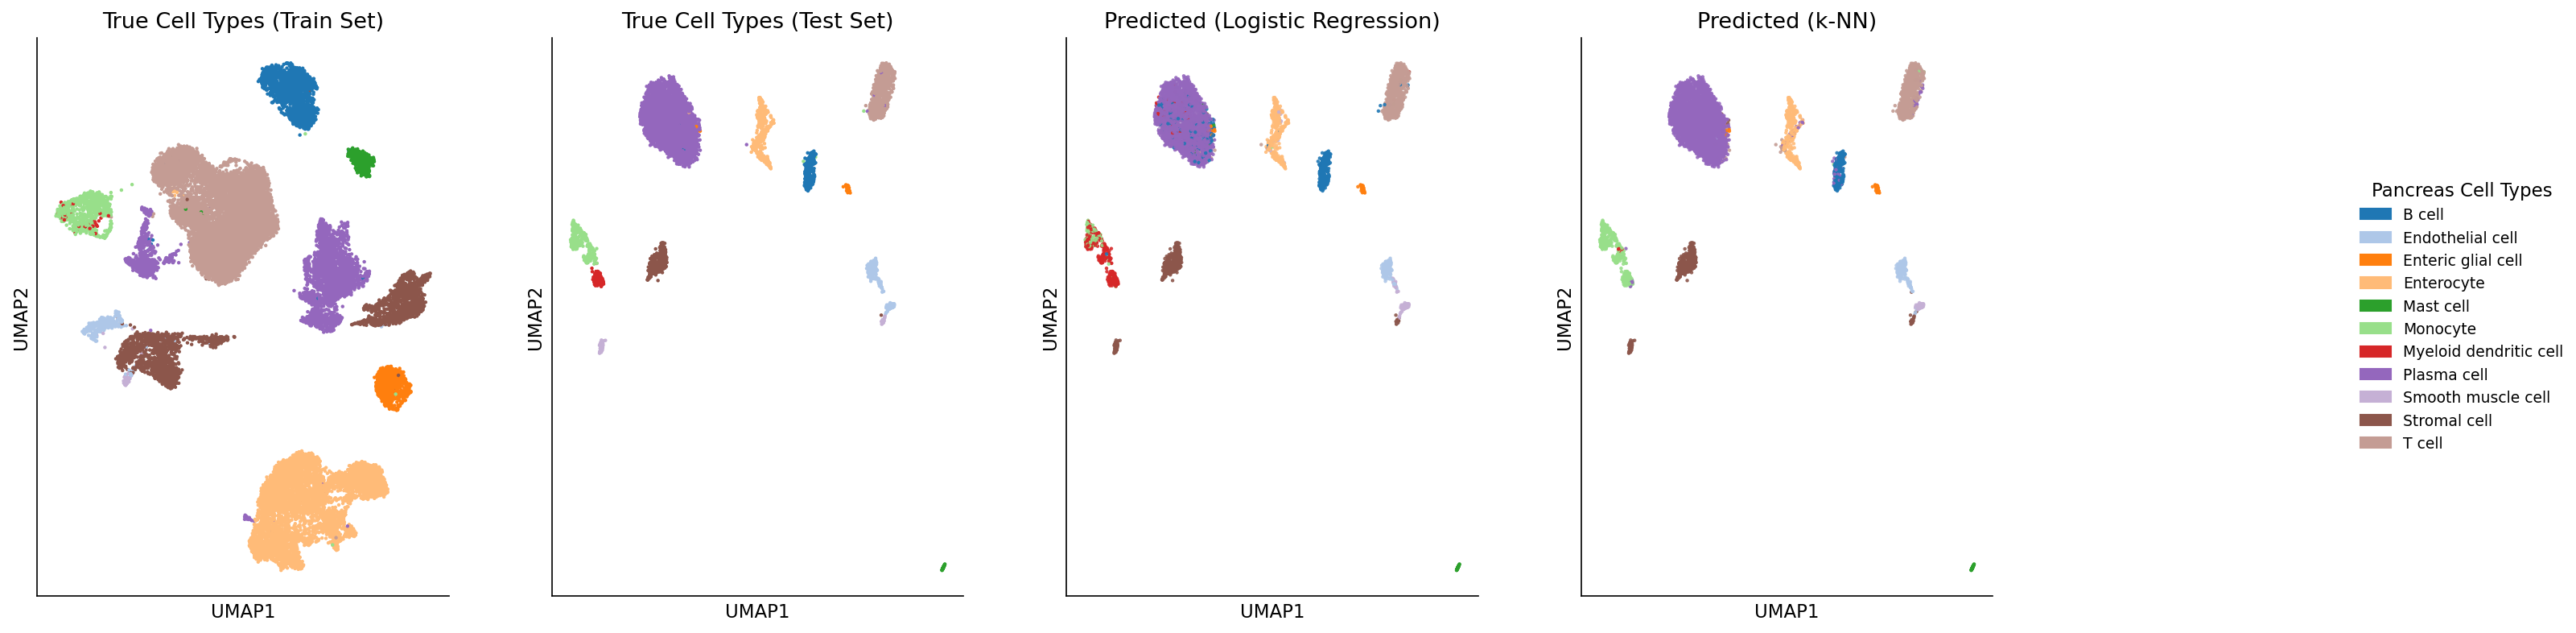

In [32]:
# --- Attach predictions to test_data ---
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# --- Tag split ---
train_data.obs["split"] = "train"
test_data.obs["split"] = "test"

# Fill missing pred columns in train_data so concat works
train_data.obs["y_pred_lr"] = "N/A"
train_data.obs["y_pred_knn"] = "N/A"

# --- Combine ---
combined = anndata.concat([train_data, test_data], join="outer")

# --- Unified label set ---
all_labels = sorted(
    set(combined.obs["cell_type"].dropna().astype(str))
    | set(combined.obs["y_pred_lr"].dropna().astype(str))
    | set(combined.obs["y_pred_knn"].dropna().astype(str))
)

# --- Color map ---
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"
color_map["N/A"] = "lightgray"

# --- Cast all to categorical with same order ---
for col in ["cell_type", "y_pred_lr", "y_pred_knn"]:
    combined.obs[col] = (
        combined.obs[col].astype(str).astype("category").cat.set_categories(all_labels)
    )

# --- Split views ---
train_view = combined[combined.obs["split"] == "train"]
test_view  = combined[combined.obs["split"] == "test"]

# --- Plot: 4 panels ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=150)

common_kwargs = dict(show=False, size=18, frameon=True, palette=color_map)

sc.pl.umap(train_view, color="cell_type",  ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Train Set)", fontsize=13)

sc.pl.umap(test_view,  color="cell_type",  ax=axes[1], **common_kwargs)
axes[1].set_title("True Cell Types (Test Set)", fontsize=13)

sc.pl.umap(test_view,  color="y_pred_lr",  ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (Logistic Regression)", fontsize=13)

sc.pl.umap(test_view,  color="y_pred_knn", ax=axes[3], alpha=0.9, **common_kwargs)
axes[3].set_title("Predicted (k-NN)", fontsize=13)

# --- Style all axes ---
for ax in axes:
    if ax.legend_:
        ax.legend_.remove()
    ax.set_facecolor("white")
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)
    ax.spines[["left", "bottom"]].set_visible(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("black")
    ax.tick_params(axis="both", which="major", labelsize=9, colors="black")

# --- Shared legend (exclude N/A) ---
legend_labels = [l for l in all_labels if l != "N/A"]
handles = [Patch(color=color_map[label], label=label) for label in legend_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1,
)
plt.subplots_adjust(right=0.80, wspace=0.25)
plt.show()

## Label Transfer Monkey=>Human

In [33]:
train_data = adata[adata.obs['species'] == 'monkey'].copy()
test_data  = adata[adata.obs['species'] == 'human'].copy()

X_train = train_data.X
X_test  = test_data.X

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [34]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.9284207296022096
                        precision    recall  f1-score   support

                B cell       0.87      1.00      0.93      2069
      Endothelial cell       0.71      0.92      0.80       348
    Enteric glial cell       0.98      1.00      0.99       848
            Enterocyte       1.00      0.99      0.99      5657
             Mast cell       0.91      0.98      0.95       393
              Monocyte       0.93      0.98      0.95       748
Myeloid dendritic cell       0.08      0.03      0.04        40
           Plasma cell       0.99      0.96      0.98      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       0.99      0.52      0.68      2597
                T cell       1.00      0.98      0.99      9979

              accuracy                           0.93     26069
             macro avg       0.77      0.76      0.75     26069
          weighted avg       0.97      0.93  

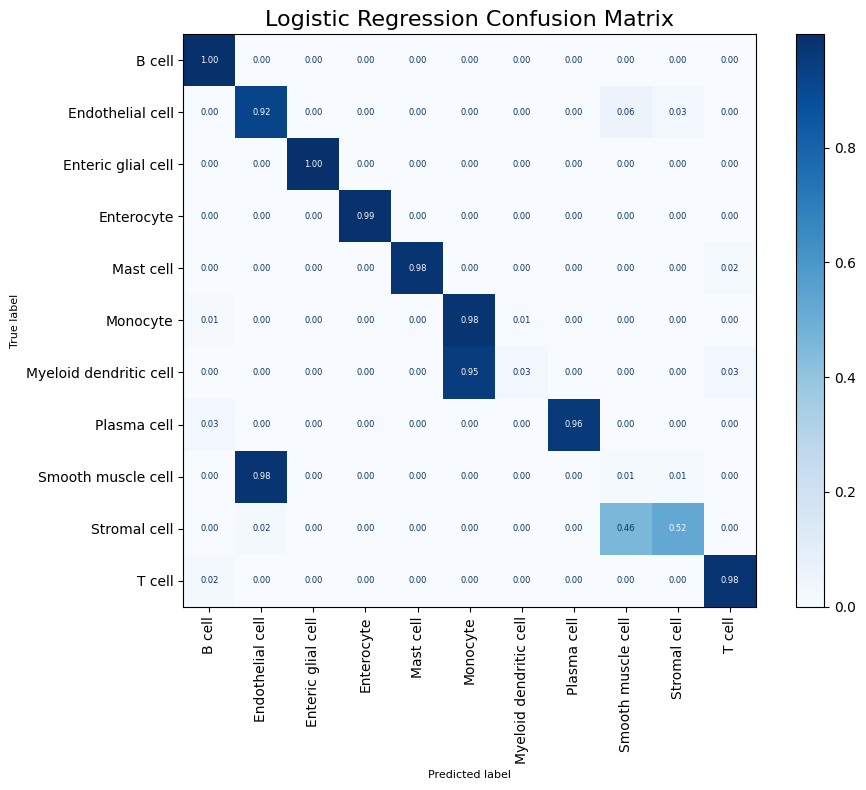


=== k-NN ===
Accuracy: 0.9265411024588592
                        precision    recall  f1-score   support

                B cell       0.94      0.99      0.96      2069
      Endothelial cell       0.70      0.91      0.79       348
    Enteric glial cell       0.99      1.00      0.99       848
            Enterocyte       0.96      0.99      0.98      5657
             Mast cell       0.96      0.98      0.97       393
              Monocyte       0.94      0.98      0.96       748
Myeloid dendritic cell       0.10      0.03      0.04        40
           Plasma cell       0.91      0.97      0.94      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       0.98      0.61      0.75      2597
                T cell       1.00      0.94      0.97      9979

              accuracy                           0.93     26069
             macro avg       0.77      0.76      0.76     26069
          weighted avg       0.96      0.93      0.94     2

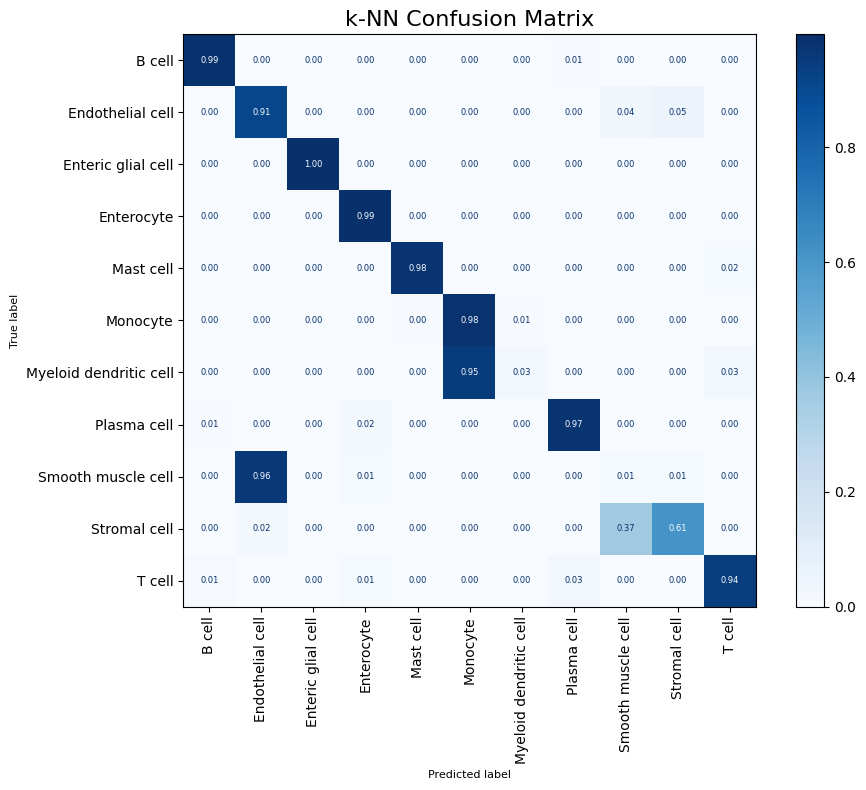

In [35]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

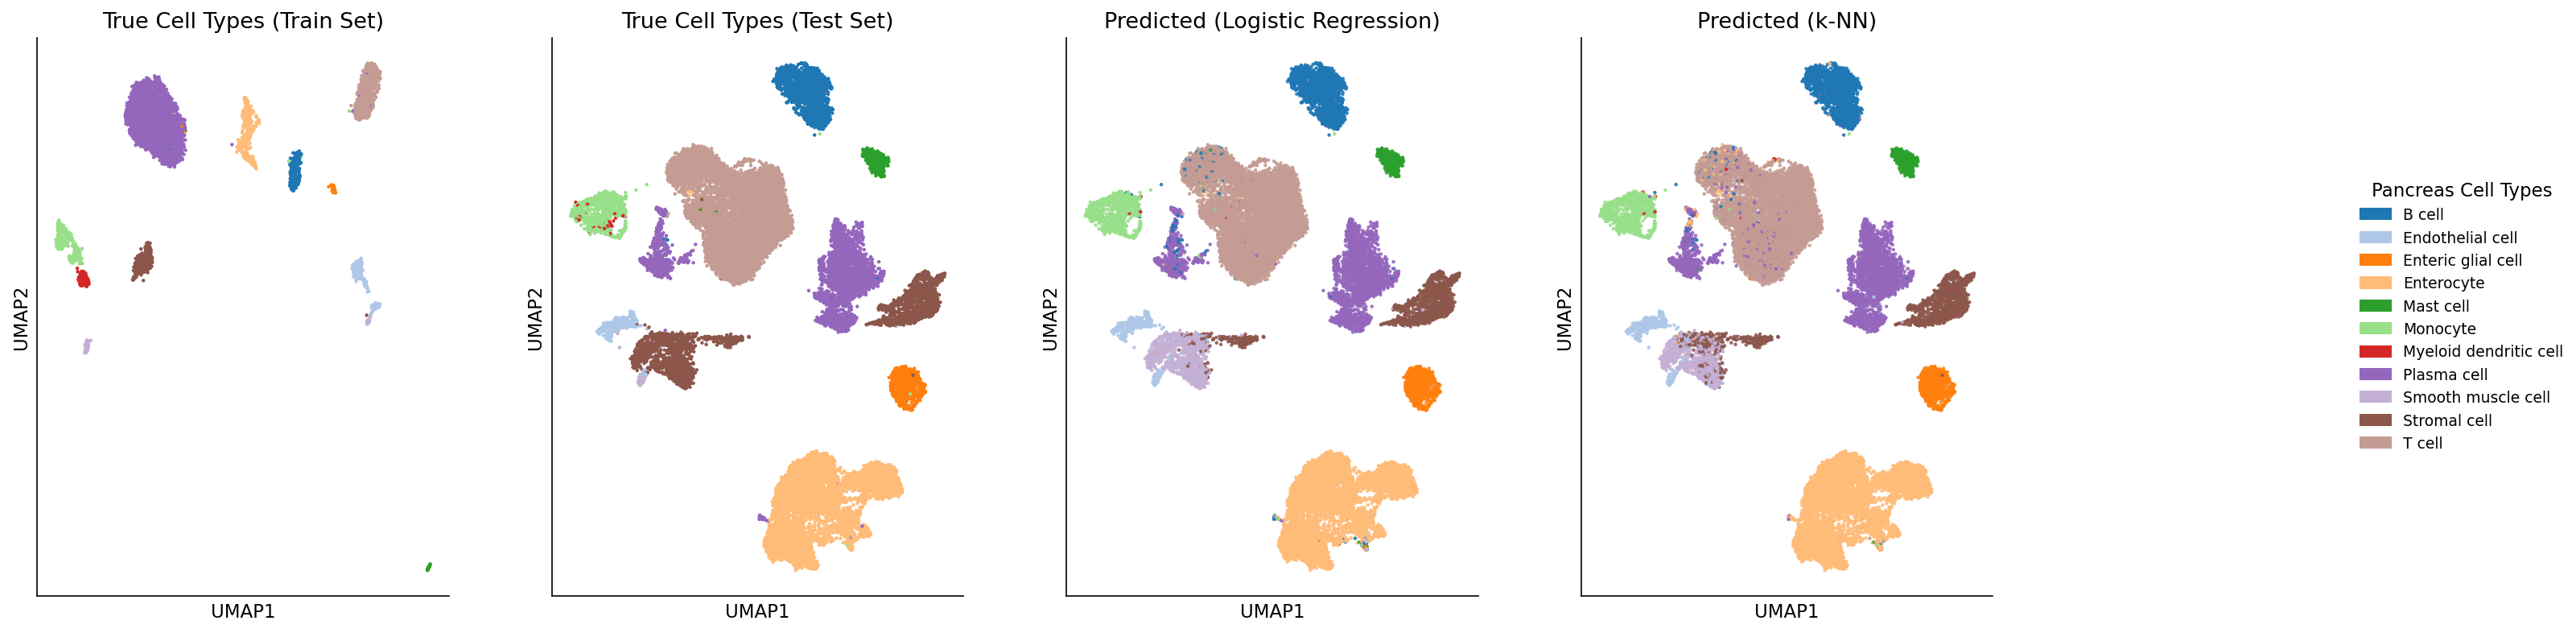

In [36]:
# --- Attach predictions to test_data ---
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# --- Tag split ---
train_data.obs["split"] = "train"
test_data.obs["split"] = "test"

# Fill missing pred columns in train_data so concat works
train_data.obs["y_pred_lr"] = "N/A"
train_data.obs["y_pred_knn"] = "N/A"

# --- Combine ---
combined = anndata.concat([train_data, test_data], join="outer")

# --- Unified label set ---
all_labels = sorted(
    set(combined.obs["cell_type"].dropna().astype(str))
    | set(combined.obs["y_pred_lr"].dropna().astype(str))
    | set(combined.obs["y_pred_knn"].dropna().astype(str))
)

# --- Color map ---
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"
color_map["N/A"] = "lightgray"

# --- Cast all to categorical with same order ---
for col in ["cell_type", "y_pred_lr", "y_pred_knn"]:
    combined.obs[col] = (
        combined.obs[col].astype(str).astype("category").cat.set_categories(all_labels)
    )

# --- Split views ---
train_view = combined[combined.obs["split"] == "train"]
test_view  = combined[combined.obs["split"] == "test"]

# --- Plot: 4 panels ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=150)

common_kwargs = dict(show=False, size=18, frameon=True, palette=color_map)

sc.pl.umap(train_view, color="cell_type",  ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Train Set)", fontsize=13)

sc.pl.umap(test_view,  color="cell_type",  ax=axes[1], **common_kwargs)
axes[1].set_title("True Cell Types (Test Set)", fontsize=13)

sc.pl.umap(test_view,  color="y_pred_lr",  ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (Logistic Regression)", fontsize=13)

sc.pl.umap(test_view,  color="y_pred_knn", ax=axes[3], alpha=0.9, **common_kwargs)
axes[3].set_title("Predicted (k-NN)", fontsize=13)

# --- Style all axes ---
for ax in axes:
    if ax.legend_:
        ax.legend_.remove()
    ax.set_facecolor("white")
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)
    ax.spines[["left", "bottom"]].set_visible(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("black")
    ax.tick_params(axis="both", which="major", labelsize=9, colors="black")

# --- Shared legend (exclude N/A) ---
legend_labels = [l for l in all_labels if l != "N/A"]
handles = [Patch(color=color_map[label], label=label) for label in legend_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1,
)
plt.subplots_adjust(right=0.80, wspace=0.25)
plt.show()